In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tempfile import mkdtemp
from joblib import Memory

# Load the dataset
data = pd.read_csv('player_valuation_dataset.csv')
data.head()

,player_id,player_name,date_of_birth,height,citizenship,is_eu,position,main_position,foot,current_club_id,...,free_agent,league_quality,relative_market_value,G/A_per_90,cards_per_90,net_per_90,net_per_90_normalized,goal_contributions_normalized,G/A_normalized_X_league_quality,age_X_position
0,100001,Carlos Auzqui (100001),1991-03-16,180.0,Argentina,False,Attack - Right Winger,Attack,right,14554,...,True,0.0,0.000000,0.99,0.000119,0.989881,-0.643272,0.225273,0.000000,Veteran_Attack
1,1000274,Brian Romero (1000274),2006-05-11,0.0,United States Mexico,False,Attack - Right Winger,Attack,NaN,78435,...,False,4.0,0.003114,0.89,0.000165,0.889835,-0.719548,-1.006767,-4.027068,Youth_Attack
2,1000273,Nimfasha Berchimas (1000273),2008-02-22,172.0,United States Burundi,False,Attack - Left Winger,Attack,right,78435,...,False,4.0,0.008303,1.45,0.000030,1.449970,-0.292495,-0.905503,-3.622014,Youth_Attack
3,1000135,Joselu Pérez (1000135),2004-03-12,183.0,Spain,True,Attack - Centre-Forward,Attack,right,8510,...,False,1.0,0.142857,1.01,0.000188,1.009812,-0.628076,-0.973012,-0.973012,Youth_Attack
4,1000284,Jed Drew (1000284),2003-08-29,176.0,Australia,False,Attack - Right Winger,Attack,right,4467,...,False,5.0,0.053269,1.62,0.000036,1.619964,-0.162889,-0.449817,-2.249086,Youth_Attack


In [14]:
## Define X/y and clean data
TARGET = "current_market_value"

print(f"Initial data: {len(data)} rows")

# Check target column
print(f"Target column: {TARGET}")
print(f"Target missing: {data[TARGET].isna().sum()}")
print(f"Target infinite: {np.isinf(data[TARGET]).sum()}")

# 1. Drop rows where target is missing or invalid
data_clean = data[data[TARGET].notna() & np.isfinite(data[TARGET])].copy()
print(f"After target cleaning: {len(data_clean)} rows")

# 2. Engineer Date Features (NEW)
# Convert string dates to datetime objects
date_cols = ['joined', 'contract_expires']
for col in date_cols:
    data_clean[col] = pd.to_datetime(data_clean[col], errors='coerce')

# Calculate durations relative to the current date
current_date = pd.Timestamp('today')
data_clean['days_since_joined'] = (current_date - data_clean['joined']).dt.days
data_clean['days_until_contract_expires'] = (data_clean['contract_expires'] - current_date).dt.days

# 3. Drop Identifiers and Raw Dates (NEW)
# We remove raw dates and IDs to prevent the OneHotEncoder from crashing the model
columns_to_drop = [
    TARGET, 'player_id', 'player_name', 'index', 'current_club_id', 'club_id', 
    'date_of_birth', 'joined', 'contract_expires', 'date_of_death', 
    'date_of_last_contract_extension', 'current_club_name', 'on_loan_from_club_name', 
    'second_club_name', 'third_club_name', 'fourth_club_name', 'citizenship'
]
cols_to_drop_existing = [c for c in columns_to_drop if c in data_clean.columns]

# Replace inf/-inf with NaN in all numeric columns
numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
data_clean[numeric_cols] = data_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)

# 4. Fix Pandas Warnings (UPDATED: removed inplace=True)
# Fill NaN in numeric columns with median (skip target)
for col in numeric_cols:
    if col != TARGET and col in data_clean.columns:
        median_val = data_clean[col].median()
        if pd.isna(median_val):
            median_val = 0  # fallback if all values are NaN
        data_clean[col] = data_clean[col].fillna(median_val)

# Fill NaN in categorical columns with 'Unknown'
categorical_cols = data_clean.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    # Ensure we don't accidentally fill date columns if any slipped through
    if col not in date_cols: 
        data_clean[col] = data_clean[col].fillna('Unknown')

# Define Final X and y
X = data_clean.drop(columns=cols_to_drop_existing)
y = data_clean[TARGET]

# Identify feature types for the pipeline
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Initial data: 33557 rows
Target column: current_market_value
Target missing: 0
Target infinite: 0
After target cleaning: 33557 rows
Train size: (26845, 40)  Test size: (6712, 40)


In [15]:
# Helper to print metrics
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s}  RMSE: {rmse:,.0f}  MAE: {mae:,.0f}  R²: {r2:.4f}")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

# ── 6. Baseline Linear Regression ──
lr_pipe = Pipeline([("pre", preprocess), ("model", LinearRegression())])
lr_pipe.fit(X_train, y_train)

results = []
results.append(evaluate("Linear Regression", y_test, lr_pipe.predict(X_test)))

Linear Regression     RMSE: 4,182,917  MAE: 1,513,583  R²: 0.5111


In [16]:
# 7. Regularized models: Ridge, Lasso, Elastic Net 
for name, model in [("Ridge", Ridge()), ("Lasso", Lasso()), ("ElasticNet", ElasticNet())]:
    pipe = Pipeline([("pre", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    results.append(evaluate(name, y_test, pipe.predict(X_test)))

Ridge                 RMSE: 4,184,549  MAE: 1,512,286  R²: 0.5107
Lasso                 RMSE: 4,182,743  MAE: 1,513,503  R²: 0.5111
ElasticNet            RMSE: 4,658,247  MAE: 1,619,005  R²: 0.3937


In [17]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# ── 8. Hyperparameter tuning via Specialized CV Estimators ──
X_train_pre = preprocess.fit_transform(X_train)
X_test_pre = preprocess.transform(X_test)

# 1. RidgeCV
ridge_cv = RidgeCV(
    alphas=[0.1, 1, 10], 
    cv=3, 
    scoring="neg_root_mean_squared_error"
)
ridge_cv.fit(X_train_pre, y_train)
print(f"Ridge best params: {{'alpha': {ridge_cv.alpha_}}}")
results.append(evaluate("Ridge (tuned)", y_test, ridge_cv.predict(X_test_pre)))

# 2. LassoCV
lasso_cv = LassoCV(
    alphas=[0.01, 0.1, 1], 
    cv=3, 
    n_jobs=-1, 
    max_iter=3000, 
    tol=1e-3, 
    selection="random"
)
lasso_cv.fit(X_train_pre, y_train)
print(f"Lasso best params: {{'alpha': {lasso_cv.alpha_}}}")
results.append(evaluate("Lasso (tuned)", y_test, lasso_cv.predict(X_test_pre)))

# 3. ElasticNetCV
enet_cv = ElasticNetCV(
    alphas=[0.01, 0.1, 1], 
    l1_ratio=[0.3, 0.7], 
    cv=3, 
    n_jobs=-1, 
    max_iter=3000, 
    tol=1e-3, 
    selection="random"
)
enet_cv.fit(X_train_pre, y_train)
print(f"ElasticNet best params: {{'alpha': {enet_cv.alpha_}, 'l1_ratio': {enet_cv.l1_ratio_}}}")
results.append(evaluate("ElasticNet (tuned)", y_test, enet_cv.predict(X_test_pre)))

print("\n── Summary ──")
print(pd.DataFrame(results).sort_values("RMSE"))

Ridge best params: {'alpha': 10.0}
Ridge (tuned)         RMSE: 4,180,726  MAE: 1,501,549  R²: 0.5116
Lasso best params: {'alpha': 0.01}
Lasso (tuned)         RMSE: 4,183,307  MAE: 1,514,292  R²: 0.5110
ElasticNet best params: {'alpha': 0.01, 'l1_ratio': 0.7}
ElasticNet (tuned)    RMSE: 4,190,971  MAE: 1,484,582  R²: 0.5092

── Summary ──
                Model          RMSE           MAE        R2
4       Ridge (tuned)  4.180726e+06  1.501549e+06  0.511607
2               Lasso  4.182743e+06  1.513503e+06  0.511136
0   Linear Regression  4.182917e+06  1.513583e+06  0.511095
5       Lasso (tuned)  4.183307e+06  1.514292e+06  0.511004
1               Ridge  4.184549e+06  1.512286e+06  0.510714
6  ElasticNet (tuned)  4.190971e+06  1.484582e+06  0.509211
3          ElasticNet  4.658247e+06  1.619005e+06  0.393668


# Next Steps

- Advanced models: RF, XGBoost, Neural Network, SVM
- **Key insight**: Log-transforming the target variable addresses skewness and improves model performance significantly

In [18]:
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest... (This might take 1-2 minutes)")

# Create the Random Forest pipeline
rf_pipe = Pipeline([
    ("pre", preprocess), 
    ("model", RandomForestRegressor(
        n_estimators=100,      # Number of trees
        max_depth=15,          # Limit depth to prevent overfitting
        random_state=42, 
        n_jobs=-1              # Use all CPU cores
    ))
])

# Train the model
rf_pipe.fit(X_train, y_train)

# Evaluate
print("\n── Random Forest Results ──")
results.append(evaluate("Random Forest", y_test, rf_pipe.predict(X_test)))

# Show updated summary
pd.DataFrame(results).sort_values("RMSE")

Training Random Forest... (This might take 1-2 minutes)

── Random Forest Results ──
Random Forest         RMSE: 3,071,037  MAE: 773,568  R²: 0.7365


,Model,RMSE,MAE,R2
7,Random Forest,3.071037e+06,7.735685e+05,0.736466
4,Ridge (tuned),4.180726e+06,1.501549e+06,0.511607
2,Lasso,4.182743e+06,1.513503e+06,0.511136
0,Linear Regression,4.182917e+06,1.513583e+06,0.511095
5,Lasso (tuned),4.183307e+06,1.514292e+06,0.511004
1,Ridge,4.184549e+06,1.512286e+06,0.510714
6,ElasticNet (tuned),4.190971e+06,1.484582e+06,0.509211
3,ElasticNet,4.658247e+06,1.619005e+06,0.393668


Tuning Random Forest and extracting Feature Importances

Best Parameters Found: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__max_features': 1.0, 'model__max_depth': 25}
Random Forest (Tuned)  RMSE: 3,099,503  MAE: 765,753  R²: 0.7316

── Updated Summary ──
                   Model          RMSE           MAE        R2
7          Random Forest  3.071037e+06  7.735685e+05  0.736466
8  Random Forest (Tuned)  3.099503e+06  7.657533e+05  0.731558
4          Ridge (tuned)  4.180726e+06  1.501549e+06  0.511607
2                  Lasso  4.182743e+06  1.513503e+06  0.511136
0      Linear Regression  4.182917e+06  1.513583e+06  0.511095
5          Lasso (tuned)  4.183307e+06  1.514292e+06  0.511004
1                  Ridge  4.184549e+06  1.512286e+06  0.510714
6     ElasticNet (tuned)  4.190971e+06  1.484582e+06  0.509211
3             ElasticNet  4.658247e+06  1.619005e+06  0.393668


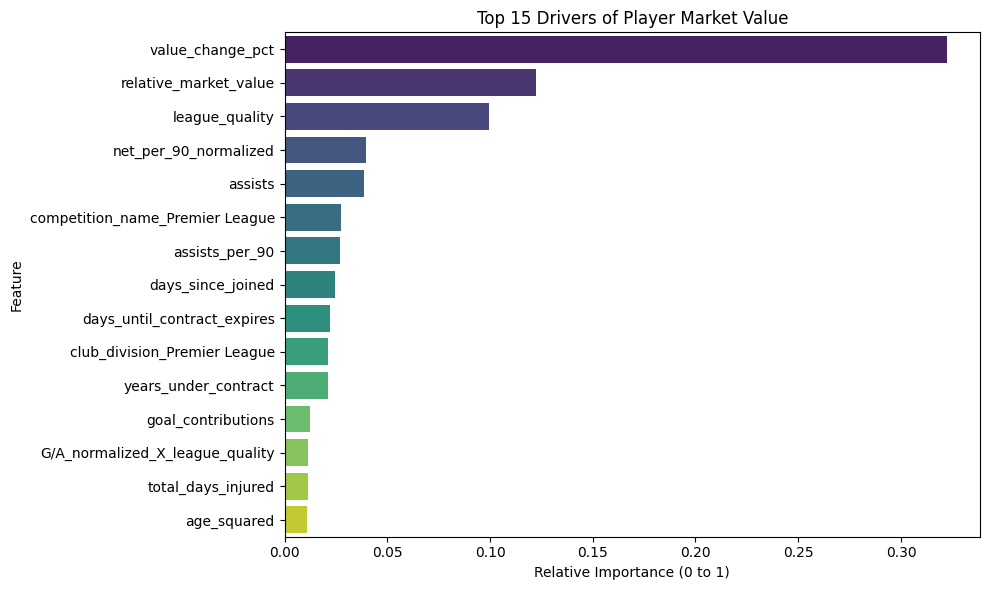

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV

print("Tuning Random Forest and extracting Feature Importances")

# 1. Define the parameters we want to test
param_grid = {
    'model__n_estimators': [100, 200, 300],          # Number of trees
    'model__max_depth': [10, 15, 20, 25, None],      # How deep the trees can go
    'model__min_samples_split': [2, 5, 10],          # Minimum samples required to split a node
    'model__max_features': ['sqrt', 'log2', 1.0]     # How many features to consider at each split
}

# 2. Run the Randomized Search
rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_grid,
    n_iter=15,               # Test 15 different random combinations
    cv=3,                    # 3-fold cross-validation
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print(f"\nBest Parameters Found: {rf_search.best_params_}")

# Evaluate the newly tuned model
results.append(evaluate("Random Forest (Tuned)", y_test, best_rf.predict(X_test)))

print("\n── Updated Summary ──")
print(pd.DataFrame(results).sort_values("RMSE"))

# 3. Extract and Plot Feature Importances
# Extract the feature names from the preprocessing step
cat_encoder = best_rf.named_steps['pre'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features)

# Extract the importance values from the Random Forest
importances = best_rf.named_steps['model'].feature_importances_

# Create a clean DataFrame for the plot
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 Most Important Features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Drivers of Player Market Value')
plt.xlabel('Relative Importance (0 to 1)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Neural Network (MLP Regressor)

**Key improvement**: We log-transform the target variable before training.  
Market values are heavily right-skewed (e.g. 100K vs 50M), which makes it very hard for gradient-based models to learn. Predicting `log(value)` and then exponentiating back fixes this and dramatically improves performance.

We also drop `value_change_pct` and `relative_market_value` to avoid data leakage (both are derived from the target).

> **Note on `feature_engineering.py`**: The engineered features (league_quality, career_phase, G/A_per_90, etc.) are already baked into `player_valuation_dataset.csv`. The feature_engineering.py script was used upstream to produce this CSV. For full reproducibility, consider importing and calling it directly in this notebook.

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── 1. Prepare data with log-transformed target ──
# Drop leakage features (both derived from the target: current_market_value)
leak_cols = [c for c in ['value_change_pct', 'relative_market_value'] if c in X_train.columns]
X_train_nn = X_train.drop(columns=leak_cols)
X_test_nn = X_test.drop(columns=leak_cols)

# Update feature lists for the new X
numeric_features_nn = X_train_nn.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_nn = X_train_nn.select_dtypes(include=["object"]).columns.tolist()

# Rebuild preprocessor without the leaked features
preprocess_nn = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_nn),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features_nn),
    ],
    remainder="drop",
)

# Log-transform the target (add 1 to handle any zero values)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Preprocess features
X_train_nn_pre = preprocess_nn.fit_transform(X_train_nn)
X_test_nn_pre = preprocess_nn.transform(X_test_nn)

# Also scale the log target for better NN convergence
from sklearn.preprocessing import StandardScaler as TargetScaler
y_scaler = TargetScaler()
y_train_scaled = y_scaler.fit_transform(y_train_log.values.reshape(-1, 1)).ravel()

print(f"Neural network input shape: {X_train_nn_pre.shape}")
print(f"Leakage features dropped: {leak_cols}")
print(f"Target range (raw): {y_train.min():,.0f} – {y_train.max():,.0f}")
print(f"Target range (log): {y_train_log.min():.2f} – {y_train_log.max():.2f}")
print(f"Target range (scaled): {y_train_scaled.min():.2f} – {y_train_scaled.max():.2f}")

Neural network input shape: (26845, 398)
Leakage features dropped: ['value_change_pct', 'relative_market_value']
Target range (raw): 10,000 – 200,000,000
Target range (log): 9.21 – 19.11
Target range (scaled): -2.19 – 4.12


In [21]:
# ── 2. Train Neural Network (MLP) on log-transformed + scaled target ──
print("Training Neural Network... (ETA: 1-3 minutes)\n")

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),  # 3 hidden layers
    activation='relu',                   # ReLU activation
    solver='adam',                        # Adam optimizer
    alpha=0.0001,                         # L2 regularization
    batch_size=256,                       # Mini-batch size
    learning_rate='adaptive',             # Reduce LR when loss plateaus
    learning_rate_init=0.001,             # Initial learning rate
    max_iter=500,                         # Max training epochs
    early_stopping=True,                  # Stop when validation loss stops improving
    validation_fraction=0.1,              # 10% of training data for validation
    n_iter_no_change=25,                  # Patience for early stopping
    random_state=42,
    verbose=False
)

# Train on scaled log target (this helps the NN converge much better)
mlp.fit(X_train_nn_pre, y_train_scaled)

print(f"Training stopped at epoch: {mlp.n_iter_}")
print(f"Final training loss: {mlp.loss_:.6f}")
print(f"Best validation score: {mlp.best_validation_score_:.6f}")

# ── 3. Predict and convert back: scaled -> log -> original ──
y_pred_scaled = mlp.predict(X_test_nn_pre)
y_pred_log = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_pred_nn = np.expm1(y_pred_log)  # Inverse of log1p

# Clip negative predictions to 0 (market value can't be negative)
y_pred_nn = np.maximum(y_pred_nn, 0)

# ── 4. Evaluate on original scale ──
print("\n── Neural Network Results ──")
nn_result = evaluate("Neural Network (MLP)", y_test, y_pred_nn)
results.append(nn_result)

print("\n── Updated Summary ──")
print(pd.DataFrame(results).sort_values("RMSE"))

Training Neural Network... (ETA: 1-3 minutes)

Training stopped at epoch: 31
Final training loss: 0.040866
Best validation score: 0.741356

── Neural Network Results ──
Neural Network (MLP)  RMSE: 3,200,966  MAE: 800,663  R²: 0.7137

── Updated Summary ──
                   Model          RMSE           MAE        R2
7          Random Forest  3.071037e+06  7.735685e+05  0.736466
8  Random Forest (Tuned)  3.099503e+06  7.657533e+05  0.731558
9   Neural Network (MLP)  3.200966e+06  8.006634e+05  0.713696
4          Ridge (tuned)  4.180726e+06  1.501549e+06  0.511607
2                  Lasso  4.182743e+06  1.513503e+06  0.511136
0      Linear Regression  4.182917e+06  1.513583e+06  0.511095
5          Lasso (tuned)  4.183307e+06  1.514292e+06  0.511004
1                  Ridge  4.184549e+06  1.512286e+06  0.510714
6     ElasticNet (tuned)  4.190971e+06  1.484582e+06  0.509211
3             ElasticNet  4.658247e+06  1.619005e+06  0.393668


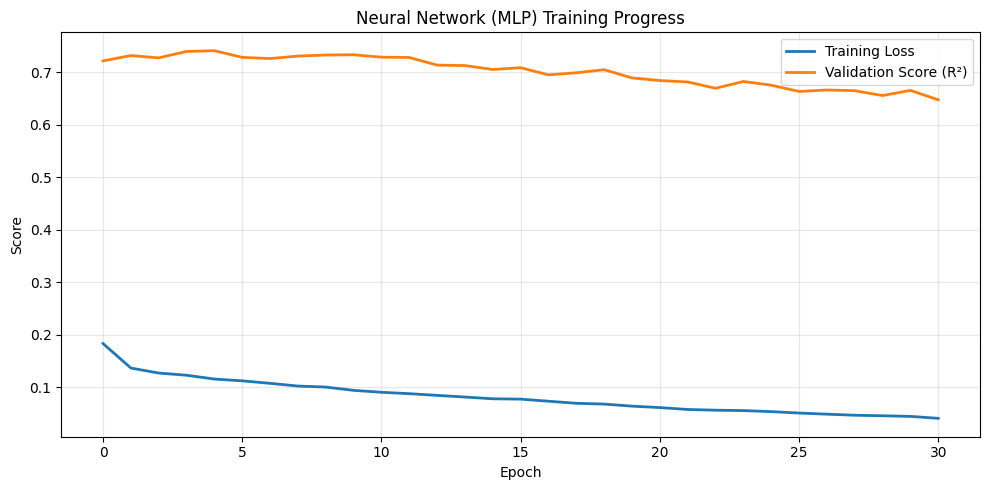

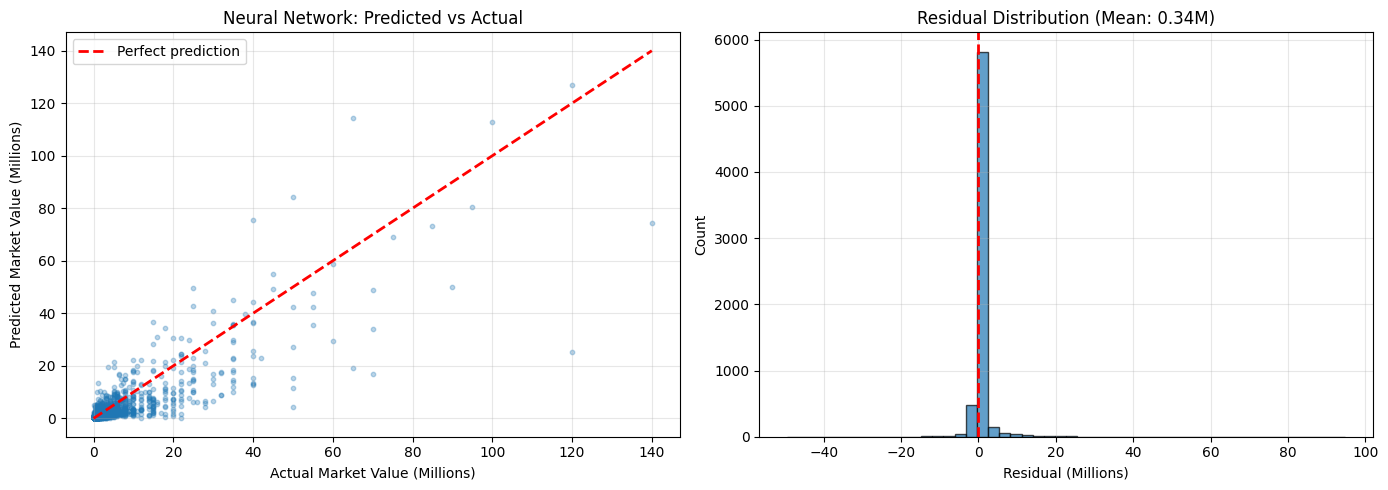

In [22]:
# ── 5. Visualize Neural Network Training Curve ──
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(mlp.loss_curve_, label='Training Loss', linewidth=2)
ax.plot(mlp.validation_scores_, label='Validation Score (R²)', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Neural Network (MLP) Training Progress')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 6. Residual Analysis ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test / 1e6, y_pred_nn / 1e6, alpha=0.3, s=10)
max_val = max(y_test.max(), max(y_pred_nn)) / 1e6
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Market Value (Millions)')
axes[0].set_ylabel('Predicted Market Value (Millions)')
axes[0].set_title('Neural Network: Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual distribution
residuals = (y_test.values - y_pred_nn) / 1e6
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residual (Millions)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution (Mean: {residuals.mean():.2f}M)')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model Evaluation & Comparison

A comprehensive comparison of all models using multiple metrics:

| Metric | What it measures | How to interpret |
|--------|-----------------|------------------|
| **RMSE** | Root Mean Squared Error — average error magnitude, penalizes large errors | Lower is better. Same units as target (euros) |
| **MAE** | Mean Absolute Error — average error magnitude, robust to outliers | Lower is better. Same units as target (euros) |
| **R²** | Coefficient of Determination — proportion of variance explained | 1.0 = perfect, 0 = same as predicting the mean, negative = worse than the mean |
| **MAPE** | Mean Absolute Percentage Error — error as a % of actual value | Lower is better. 10% = on average, predictions are 10% off |
| **MedAE** | Median Absolute Error — the "typical" error (ignores outliers) | Lower is better. More robust than MAE for skewed targets |
| **Max Error** | Worst single prediction error | Lower is better. Shows worst-case scenario |

In [23]:
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    median_absolute_error, max_error, mean_absolute_percentage_error
)

# ── Collect all model predictions ──
# Re-generate predictions for all models to ensure consistency
model_predictions = {
    "Linear Regression": lr_pipe.predict(X_test),
    "Ridge (tuned)": ridge_cv.predict(X_test_pre),
    "Lasso (tuned)": lasso_cv.predict(X_test_pre),
    "ElasticNet (tuned)": enet_cv.predict(X_test_pre),
    "Random Forest": rf_pipe.predict(X_test),
    "Random Forest (Tuned)": best_rf.predict(X_test),
    "Neural Network (MLP)": y_pred_nn,
}

# ── Compute comprehensive metrics for each model ──
def full_evaluate(name, y_true, y_pred):
    """Compute all evaluation metrics for a model."""
    # Clip predictions to avoid negative values
    y_pred = np.maximum(y_pred, 0)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    med_ae = median_absolute_error(y_true, y_pred)
    max_err = max_error(y_true, y_pred)
    
    # MAPE: avoid division by zero for very small actual values
    mask = y_true > 1000  # only compute MAPE for values > 1000€
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = np.nan
    
    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "MedAE": med_ae,
        "R²": r2,
        "MAPE (%)": mape,
        "Max Error": max_err,
    }

# Build the full comparison table
full_results = []
for name, preds in model_predictions.items():
    full_results.append(full_evaluate(name, y_test.values, preds))

metrics_df = pd.DataFrame(full_results).sort_values("R²", ascending=False)

# ── Format and display ──
print("=" * 100)
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 100)

# Format numbers for readability
display_df = metrics_df.copy()
display_df["RMSE"] = display_df["RMSE"].apply(lambda x: f"{x:,.0f}")
display_df["MAE"] = display_df["MAE"].apply(lambda x: f"{x:,.0f}")
display_df["MedAE"] = display_df["MedAE"].apply(lambda x: f"{x:,.0f}")
display_df["R²"] = display_df["R²"].apply(lambda x: f"{x:.4f}")
display_df["MAPE (%)"] = display_df["MAPE (%)"].apply(lambda x: f"{x:.1f}%")
display_df["Max Error"] = display_df["Max Error"].apply(lambda x: f"{x:,.0f}")

print(display_df.to_string(index=False))
print()

# ── Identify the best model per metric ──
print("── Best Model per Metric ──")
for col in ["RMSE", "MAE", "MedAE", "R²", "MAPE (%)", "Max Error"]:
    if col == "R²":
        best_idx = metrics_df[col].idxmax()
    else:
        best_idx = metrics_df[col].idxmin()
    print(f"  {col:12s} → {metrics_df.loc[best_idx, 'Model']}")

COMPREHENSIVE MODEL EVALUATION
                Model      RMSE       MAE   MedAE     R² MAPE (%)   Max Error
        Random Forest 3,071,037   773,568 123,670 0.7365    95.5%  84,517,648
Random Forest (Tuned) 3,099,503   765,753 105,554 0.7316    82.1%  85,290,000
 Neural Network (MLP) 3,200,966   800,663 106,080 0.7137    81.3%  94,838,064
        Ridge (tuned) 4,140,722 1,282,360 389,067 0.5209   333.1% 123,083,359
    Linear Regression 4,141,080 1,287,143 383,674 0.5208   338.1% 123,040,484
        Lasso (tuned) 4,141,461 1,287,810 386,547 0.5207   338.4% 123,041,757
   ElasticNet (tuned) 4,154,828 1,279,811 400,000 0.5176   326.6% 123,127,209

── Best Model per Metric ──
  RMSE         → Random Forest
  MAE          → Random Forest (Tuned)
  MedAE        → Random Forest (Tuned)
  R²           → Random Forest
  MAPE (%)     → Neural Network (MLP)
  Max Error    → Random Forest


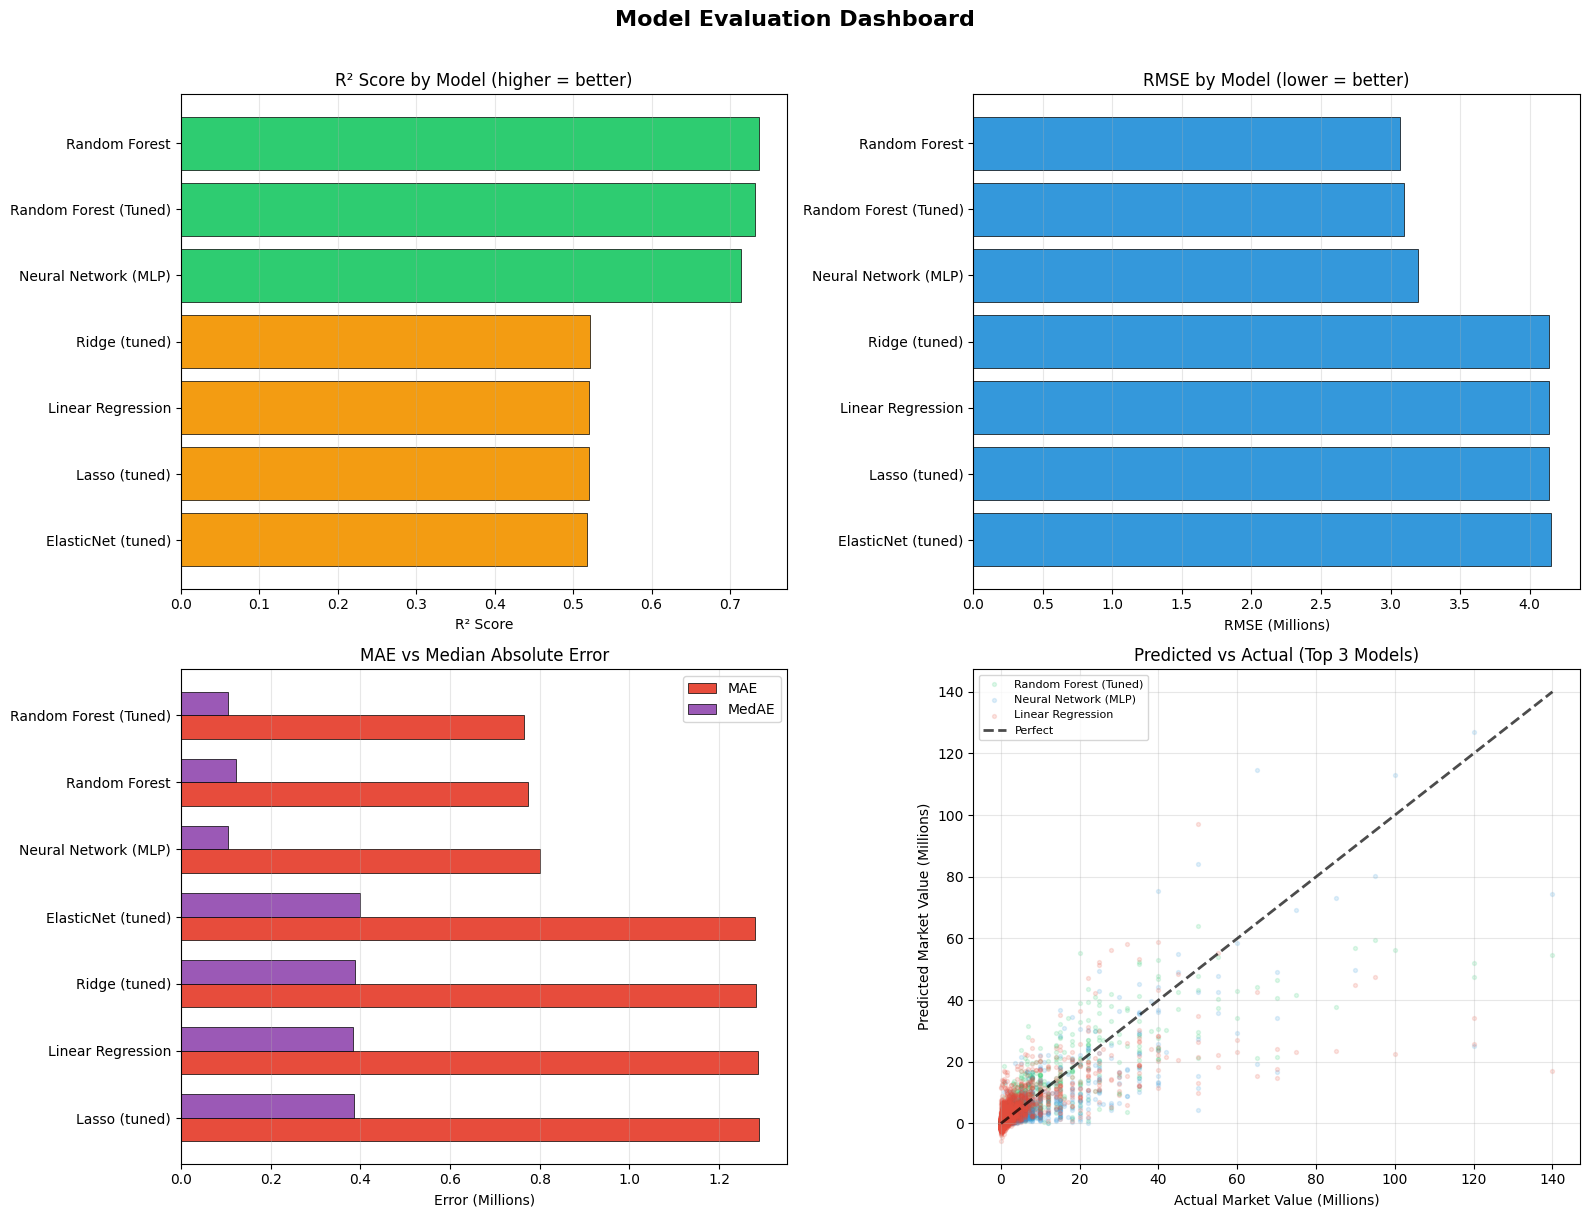

In [24]:
# ── Visual Comparison of All Models ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Score Comparison (bar chart)
ax = axes[0, 0]
models_sorted = metrics_df.sort_values("R²", ascending=True)
colors = ['#e74c3c' if r2 < 0 else '#2ecc71' if r2 > 0.7 else '#f39c12' if r2 > 0.5 else '#e67e22' 
          for r2 in models_sorted["R²"]]
ax.barh(models_sorted["Model"], models_sorted["R²"], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel("R² Score")
ax.set_title("R² Score by Model (higher = better)")
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')

# 2. RMSE Comparison (bar chart)
ax = axes[0, 1]
models_sorted = metrics_df.sort_values("RMSE", ascending=False)
ax.barh(models_sorted["Model"], models_sorted["RMSE"] / 1e6, color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_xlabel("RMSE (Millions)")
ax.set_title("RMSE by Model (lower = better)")
ax.grid(True, alpha=0.3, axis='x')

# 3. MAE vs MedAE grouped bar chart
ax = axes[1, 0]
models_sorted = metrics_df.sort_values("MAE", ascending=False)
y_pos = np.arange(len(models_sorted))
width = 0.35
ax.barh(y_pos - width/2, models_sorted["MAE"] / 1e6, width, label='MAE', color='#e74c3c', edgecolor='black', linewidth=0.5)
ax.barh(y_pos + width/2, models_sorted["MedAE"] / 1e6, width, label='MedAE', color='#9b59b6', edgecolor='black', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(models_sorted["Model"])
ax.set_xlabel("Error (Millions)")
ax.set_title("MAE vs Median Absolute Error")
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# 4. Predicted vs Actual for best models
ax = axes[1, 1]
best_models = {
    "Random Forest (Tuned)": model_predictions["Random Forest (Tuned)"],
    "Neural Network (MLP)": model_predictions["Neural Network (MLP)"],
    "Linear Regression": model_predictions["Linear Regression"],
}
colors_scatter = ['#2ecc71', '#3498db', '#e74c3c']
for (name, preds), color in zip(best_models.items(), colors_scatter):
    ax.scatter(y_test / 1e6, preds / 1e6, alpha=0.15, s=8, color=color, label=name)
max_val = y_test.max() / 1e6
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='Perfect', alpha=0.7)
ax.set_xlabel("Actual Market Value (Millions)")
ax.set_ylabel("Predicted Market Value (Millions)")
ax.set_title("Predicted vs Actual (Top 3 Models)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Model Evaluation Dashboard", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()